In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ast import literal_eval

In [2]:
bd= pd.read_csv('datafixed_bolide_data.csv') #the index for bolide 1 is 12

In [3]:
b11= bd.iloc[265]

In [4]:
b11['datetime']

'2024-09-19,09:52:50.108723+00:00'

In [5]:
lat= literal_eval(b11['lat_stereo_g18'])
long= literal_eval(b11['lon_stereo_g18'])
alt= literal_eval(b11['alt_stereo_g18'])
energy = literal_eval(b11['energyJoules_stereo_g18'])

In [6]:
def findtheta(lat, long, alt):
    x= np.abs(lat[-1]-lat[0])*0.0175
    y= np.abs(long[-1]-long[0])*0.0175
    z= np.abs(alt[-1]-alt[0])*0.0175
    return np.arctan((np.sqrt(x**2+y**2))/z)

def degtom(theta, r=6378137): #r in m
    rad= theta*0.0175
    return r*rad

def airrho(z, H=8500): #calculates density based on rho naught, height, and scale height
                                    #8.5 km is the scale height for Earth and 1.225 kg/m^3 is the density of air at sea level
    return (rho0*(1/(np.e**(z/H))))

H=8500 #meters
rho0= 1.225 #kg/m^3
rockyrho = 3500 #kg/m^3
metalrho = 7500 #kg/m^3 #constants for bolide density based on possible composition
icyrho = 750 #kg/m^3

In [7]:
print (len(lat), len(long), len(alt), len(energy))

112 112 112 112


In [8]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        print(i) #determine the index at which the bolide catastrophically destructs

25


In [9]:
totalmass= 0
totalh= 0 
for i in range (25): 
    deltalat = np.abs(degtom(lat[i+1]-lat[i])) #change in lat converted to meters 
    deltalong = np.abs(degtom(long[i+1]-long[i]))
    deltaalt = (np.abs(alt[i+1]-alt[i]))*1000 #multipled by 1000 to convert to meters
    h= np.sqrt(deltalat**2 + deltalong**2 + deltaalt**2)
    totalh= totalh+h 

    altm = (alt[i]+alt[i+1])*1000
    rho = airrho((1/2)*altm)
    totalmass = totalmass+(h*rho)

In [10]:
rrocky = (3/4)*(totalmass/rockyrho)
rmetal = (3/4)*(totalmass/metalrho)
ricy = (3/4)*(totalmass/icyrho)

print (rrocky, rmetal, ricy) #this unit is METERS 

0.25713177847181623 0.11999482995351424 1.1999482995351425


In [11]:
totalh

50585.08712978513

In [12]:
for i in range(len(alt)-1):
    print (alt[i]-alt[i+1])

0.004801110000002495
0.0035009599999966667
0.006099970000001065
5.546978959999997
0.10810434000000413
-0.1142367700000051
0.04867830999999967
0.02945981000000586
-0.027270360000002825
0.017357140000001436
0.0008640499999970075
0.0008636700000010933
0.0008677800000000957
1.2754995200000039
-0.12855411000000316
0.025564310000000035
-0.07956494999999819
-0.020657130000003576
0.07251817000000216
0.09792853999999807
0.08127551999999838
0.23375272000000535
12.060768239999998
-1.5999451100000002
-10.322378359999998
0.134837509999997
0.05992361999999929
0.18509407000000522
0.07657992999999408
0.19015193000000608
0.1268579299999999
0.29162821999999977
0.12801742999999988
0.2643804000000003
0.1249245099999996
0.28982013999999623
0.07900599999999969
0.22462722000000213
0.10702631000000196
0.24087074999999913
0.14047262999999788
0.046378410000002646
0.04681637999999566
0.04069942000000282
0.04423996999999957
0.10936123999999836
0.21624845000000192
0.14133393000000183
0.1366043399999981
0.129932159

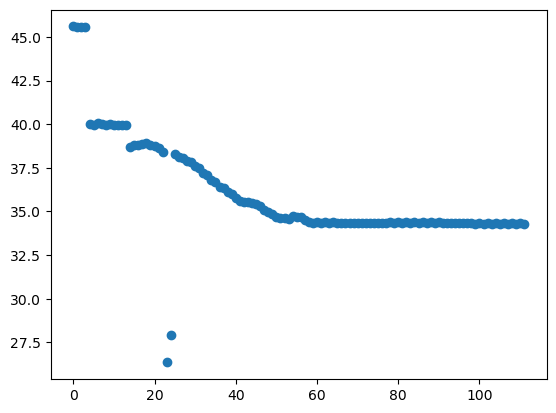

In [13]:
plt.scatter(range(len(alt)), alt)